# Phase 4 — Sentiment Analysis (ML + DL)

Train traditional ML and deep learning models on Phase 2 cleaned text, evaluate performance, and export **`sentiment_results_phase4.csv`**.

**Input:** `cleaned_reviews_phase2.csv` from Phase 2  
**Labels:** `target` — `0` = negative, `2` = neutral, `4` = positive

> **Note:** ML models use the **full dataset** (~1.5M rows). RNN/LSTM **subsample by default** (`MAX_NN_SAMPLES=150_000`) because CPU training on all rows takes ~30+ min per model. Restart kernel before re-running if you hit `MemoryError`.

> **Python 3.13+:** TensorFlow may not install — the notebook auto-falls back to **Keras + PyTorch** for RNN/LSTM.  
> **DistilBERT (Step 10):** Enabled by default (`RUN_BERT = True`). Run the Install cell for `transformers` + `torch`.

```bash
pip install pandas scikit-learn joblib matplotlib seaborn
pip install tensorflow          # Python <= 3.12
pip install keras torch         # Python 3.13+ fallback
pip install transformers torch  # optional — Step 10 BERT
```

## Install dependencies (run once)

In [1]:
import subprocess
import sys

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "pandas", "scikit-learn", "joblib", "matplotlib", "seaborn"]
)

try:
    import tensorflow as tf  # noqa: F401
    print(f"TensorFlow {tf.__version__} already installed.")
except ImportError:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
        import tensorflow as tf  # noqa: F401
        print(f"TensorFlow {tf.__version__} installed.")
    except Exception:
        print("TensorFlow not available for this Python version — installing Keras + PyTorch backend.")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "keras", "torch"])
        print("Installed keras + torch. Restart kernel, then re-run Setup and Step 7+.")

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "transformers", "torch", "accelerate"]
)
print("Installed transformers + torch for DistilBERT (Step 10).")


Python 3.14.4
TensorFlow not available for this Python version — installing Keras + PyTorch backend.
Installed keras + torch. Restart kernel, then re-run Setup and Step 7+.
Installed transformers + torch for DistilBERT (Step 10).


## Setup — Imports, configuration, and helpers

In [2]:
from __future__ import annotations

import gc
import os
import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().resolve()
INPUT_CSV = PROJECT_DIR / "cleaned_reviews_phase2.csv"
OUTPUT_CSV = PROJECT_DIR / "sentiment_results_phase4.csv"
VECTORIZER_PATH = PROJECT_DIR / "tfidf_vectorizer_phase4.joblib"
MODELS_DIR = PROJECT_DIR / "phase4_models"
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Parallel processing
CPU_COUNT = os.cpu_count() or 4
N_JOBS = -1  # sklearn / joblib: all cores
NUM_WORKERS = max(1, min(4, CPU_COUNT - 1))  # cap workers to reduce RAM spikes
PARALLEL_TEXT_JOBS = max(1, min(4, CPU_COUNT // 2))  # text keyword/complaint steps
os.environ.setdefault("OMP_NUM_THREADS", str(CPU_COUNT))
os.environ.setdefault("MKL_NUM_THREADS", str(CPU_COUNT))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "true")

# None = use complete dataset (no sampling)
MAX_ML_SAMPLES: Optional[int] = None
# DL on 1.5M rows on CPU is very slow — subsample for RNN/LSTM (ML still uses full data)
MAX_NN_SAMPLES: Optional[int] = 150_000
MAX_BERT_SAMPLES: Optional[int] = None
OUTPUT_MAX_ROWS: Optional[int] = None

RUN_BERT = True
RUN_LSTM = True  # set False to skip Step 9 after RNN
BERT_EPOCHS = 2
BERT_MAX_LENGTH = 128

# Neural-network speed knobs (Steps 7–9)
NN_MAX_VOCAB = 12_000
NN_MAX_SEQ_LEN = 60          # Twitter-length text; shorter = faster RNN steps
NN_EMBED_DIM = 64
NN_RNN_UNITS = 32
NN_EPOCHS = 2
NN_BATCH_SIZE = 2048
NN_PREDICT_BATCH_SIZE = 4096
NN_VAL_SPLIT = 0.05
NN_EVAL_MAX_SAMPLES: Optional[int] = 30_000  # cap test predict for metrics/plots
BERT_TRAIN_BATCH = 32
BERT_EVAL_BATCH = 64

SENTIMENT_MAP: Dict[int, str] = {0: "Negative", 2: "Neutral", 4: "Positive"}
TARGET_VALUES = [0, 2, 4]


def map_sentiment_label(value) -> str:
    try:
        key = int(value)
    except (TypeError, ValueError):
        return "Unknown"
    return SENTIMENT_MAP.get(key, "Unknown")

COMPLAINT_RULES: Dict[str, List[str]] = {
    "delivery_issue": ["delivery", "shipping", "ship", "late", "delay", "arrive", "package"],
    "product_quality": ["broken", "defect", "quality", "cheap", "damage", "fake", "poor"],
    "refund_issue": ["refund", "return", "money back", "chargeback"],
    "customer_service": ["support", "service", "rude", "agent", "call", "help", "response"],
    "pricing_issue": ["price", "expensive", "overpriced", "cost", "fee", "charge"],
}



def nn_eval_subset(X_seq: np.ndarray, y_series: pd.Series, max_samples: Optional[int], seed: int = RANDOM_STATE):
    """Use a stratified subset for DL predict/metrics (much faster on large test sets)."""
    if max_samples is None or len(X_seq) <= max_samples:
        return X_seq, y_series
    y_arr = y_series.to_numpy()
    idx_parts = []
    per_class = max(1, max_samples // len(np.unique(y_arr)))
    rng = np.random.default_rng(seed)
    for label in np.unique(y_arr):
        label_idx = np.flatnonzero(y_arr == label)
        take = min(len(label_idx), per_class)
        idx_parts.append(rng.choice(label_idx, size=take, replace=False))
    idx = np.concatenate(idx_parts)
    if len(idx) > max_samples:
        idx = rng.choice(idx, size=max_samples, replace=False)
    return X_seq[idx], y_series.iloc[idx]

print(f"Project directory: {PROJECT_DIR}")
print(f"Parallel: CPU_COUNT={CPU_COUNT}, N_JOBS={N_JOBS}, NUM_WORKERS={NUM_WORKERS}")
def _sample_mode(name: str, n: Optional[int]) -> str:
    return f"{name}=full" if n is None else f"{name}={n:,}"

print(
    f"Data mode: {_sample_mode('ML', MAX_ML_SAMPLES)}, "
    f"{_sample_mode('NN', MAX_NN_SAMPLES)}, "
    f"{_sample_mode('BERT', MAX_BERT_SAMPLES)}"
)
print(
    f"NN config: seq={NN_MAX_SEQ_LEN}, vocab={NN_MAX_VOCAB:,}, "
    f"batch={NN_BATCH_SIZE}, eval_cap={NN_EVAL_MAX_SAMPLES}"
)
try:
    import tensorflow as tf

    gpus = tf.config.list_physical_devices("GPU")
    msg = "yes (GPU detected)" if gpus else "yes (CPU only)"
    print(f"TensorFlow available: {msg}")
except Exception as exc:
    print(f"TensorFlow available: no — {exc}")
    try:
        import keras
        import torch

        torch.set_num_threads(CPU_COUNT)
        print(f"Keras fallback: yes ({keras.__version__}, PyTorch threads={CPU_COUNT})")
    except Exception:
        print("Keras fallback available: no — run Install cell, restart kernel, then continue")


Project directory: D:\NCPL\Bootcamp\Projects\Project 5\new data\data 2
Parallel: CPU_COUNT=8, N_JOBS=-1, NUM_WORKERS=4
Data mode: ML=full, NN=150,000, BERT=full
NN config: seq=60, vocab=12,000, batch=2048, eval_cap=30000
TensorFlow available: no — No module named 'tensorflow'
Keras fallback available: no — run Install cell, restart kernel, then continue


---
## Step 1 — Load cleaned data

Load Phase 2 output, standardize `review_text` and `target`, handle missing text, and show class distribution.

Dropping 352 rows with missing review_text.
Loaded 1,565,497 rows from cleaned_reviews_phase2.csv
Class distribution


,target,label,count,pct
0,0,Negative,781567,49.92
1,4,Positive,783930,50.08


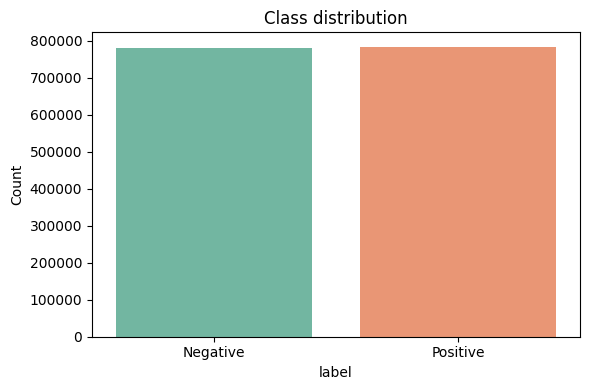

In [3]:
def resolve_review_text_column(df: pd.DataFrame) -> str:
    for col in ("text_lemmatized", "text_clean", "text_no_stopwords", "text", "review_text"):
        if col in df.columns:
            return col
    raise ValueError(f"No review text column found. Columns: {list(df.columns)}")


def safe_text(value) -> str:
    if pd.isna(value):
        return ""
    return str(value).strip()


def load_phase2_data(path: Path) -> pd.DataFrame:
    """Load only modeling columns to avoid MemoryError on ~1.5M rows."""
    if not path.is_file():
        raise FileNotFoundError(
            f"{path.name} not found. Run phase2_text_cleaning.ipynb first."
        )

    header_df = pd.read_csv(path, nrows=0)
    if "target" not in header_df.columns:
        raise ValueError("Column target is required (0=negative, 2=neutral, 4=positive).")

    text_col = resolve_review_text_column(header_df)
    usecols = ["target", text_col]
    if "row_id" in header_df.columns:
        usecols = ["row_id", "target", text_col]

    df = pd.read_csv(path, usecols=usecols)
    if df.empty:
        raise ValueError("Loaded dataframe is empty.")

    df["review_text"] = df[text_col].map(safe_text)
    if text_col != "review_text":
        df.drop(columns=[text_col], inplace=True)

    keep = df["review_text"].ne("") & ~df["review_text"].str.lower().eq("missing_review")
    if (~keep).any():
        print(f"Dropping {(~keep).sum():,} rows with missing review_text.")
        df = df.loc[keep]

    df["target"] = pd.to_numeric(df["target"], errors="coerce")
    bad_target = df["target"].isna()
    if bad_target.any():
        print(f"Dropping {bad_target.sum():,} rows with invalid target.")
        df = df.loc[~bad_target]

    df["target"] = df["target"].astype(np.int8)
    unknown = ~df["target"].isin(TARGET_VALUES)
    if unknown.any():
        print(f"Dropping {unknown.sum():,} rows with unknown target values.")
        df = df.loc[~unknown]

    df.reset_index(drop=True, inplace=True)
    gc.collect()
    return df


def show_class_distribution(y: pd.Series, title: str = "Class distribution") -> pd.DataFrame:
    counts = y.value_counts().sort_index()
    dist = pd.DataFrame({
        "target": counts.index,
        "label": counts.index.map(SENTIMENT_MAP),
        "count": counts.values,
        "pct": (100.0 * counts / counts.sum()).round(2).values,
    })
    print(title)
    display(dist)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=dist, x="label", y="count", hue="label", palette="Set2", legend=False)
    plt.title(title)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    return dist


df = load_phase2_data(INPUT_CSV)
print(f"Loaded {len(df):,} rows from {INPUT_CSV.name}")
class_dist = show_class_distribution(df["target"])


---
## Step 2 — Train / test split

Stratified split on `target` so each sentiment class is represented in train and test.

Using full dataset: 1,565,497 rows.
Train: 1,252,397 | Test: 313,100
Train set distribution


,target,label,count,pct
0,0,Negative,625253,49.92
1,4,Positive,627144,50.08


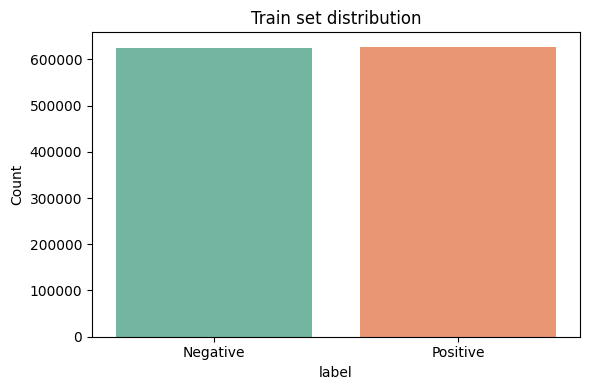

Test set distribution


,target,label,count,pct
0,0,Negative,156314,49.92
1,4,Positive,156786,50.08


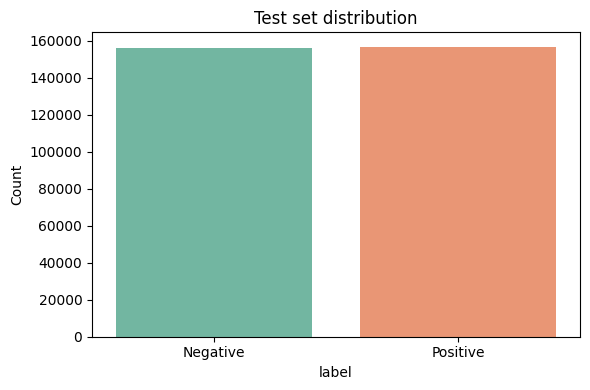

,target,label,count,pct
0,0,Negative,156314,49.92
1,4,Positive,156786,50.08


In [4]:
def stratified_sample(df: pd.DataFrame, max_rows: Optional[int], random_state: int) -> pd.DataFrame:
    """Stratified sample that keeps all columns (pandas 3.x groupby.apply drops grouping cols)."""
    if "target" not in df.columns:
        raise KeyError("Column 'target' missing. Re-run Step 1 before sampling.")
    if max_rows is None or len(df) <= max_rows:
        print(f"Using full dataset: {len(df):,} rows.")
        return df

    parts = []
    for label, group in df.groupby("target", sort=False):
        n = max(1, int(round(len(group) * max_rows / len(df))))
        parts.append(group.sample(n=min(n, len(group)), random_state=random_state))

    sampled = pd.concat(parts, ignore_index=True)
    if len(sampled) > max_rows:
        sampled = sampled.sample(max_rows, random_state=random_state).reset_index(drop=True)
    print(f"Sampled {len(sampled):,} rows (from {len(df):,}) for modeling.")
    return sampled


df_ml = stratified_sample(df, MAX_ML_SAMPLES, RANDOM_STATE)
X = df_ml["review_text"]
y = df_ml["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
show_class_distribution(y_train, title="Train set distribution")
show_class_distribution(y_test, title="Test set distribution")


---
## Step 3 — Text vectorization (TF-IDF)

Fit a TF-IDF vectorizer with unigrams and bigrams. The fitted vectorizer is saved for later inference.

In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

try:
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
except ValueError as exc:
    raise RuntimeError(f"TF-IDF failed — check for empty review_text: {exc}") from exc

joblib.dump(tfidf, VECTORIZER_PATH)
print(f"TF-IDF shape: train {X_train_tfidf.shape}, test {X_test_tfidf.shape}")
print(f"Vectorizer saved to {VECTORIZER_PATH.name}")


TF-IDF shape: train (1252397, 50000), test (313100, 50000)
Vectorizer saved to tfidf_vectorizer_phase4.joblib


---
## Step 4 — Model 1: Multinomial Naive Bayes

Train Naive Bayes on TF-IDF features and report accuracy, precision, recall, F1, and confusion matrix.


=== Multinomial Naive Bayes ===
Accuracy    : 0.7664
Precision   : 0.7664
Recall      : 0.7664
F1          : 0.7664

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76    156314
           4       0.76      0.77      0.77    156786

    accuracy                           0.77    313100
   macro avg       0.77      0.77      0.77    313100
weighted avg       0.77      0.77      0.77    313100



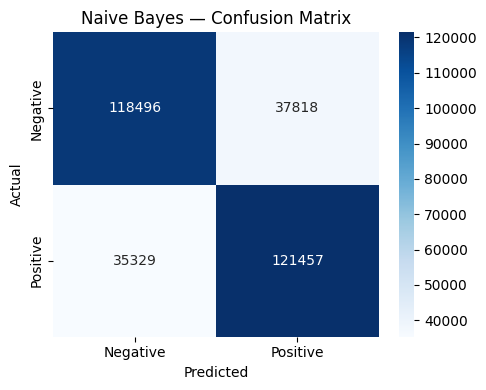

['D:\\NCPL\\Bootcamp\\Projects\\Project 5\\new data\\data 2\\phase4_models\\naive_bayes.joblib']

In [6]:
def evaluate_classifier(name: str, y_true, y_pred, labels: Sequence[int]) -> dict:
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k.capitalize():12s}: {v:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=list(labels), zero_division=0))
    return metrics


def plot_confusion_matrix(y_true, y_pred, labels: Sequence[int], title: str) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=list(labels))
    label_names = [SENTIMENT_MAP.get(l, str(l)) for l in labels]
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


labels_present = sorted(y_train.unique())

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_proba = nb_model.predict_proba(X_test_tfidf)

nb_metrics = evaluate_classifier("Multinomial Naive Bayes", y_test, nb_pred, labels_present)
plot_confusion_matrix(y_test, nb_pred, labels_present, "Naive Bayes — Confusion Matrix")
joblib.dump(nb_model, MODELS_DIR / "naive_bayes.joblib")


---
## Step 5 — Model 2: Linear SVM

Train `LinearSVC` and evaluate. Important keywords are extracted from learned coefficients.


=== Linear SVM ===
Accuracy    : 0.7798
Precision   : 0.7803
Recall      : 0.7798
F1          : 0.7797

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.77    156314
           4       0.77      0.80      0.78    156786

    accuracy                           0.78    313100
   macro avg       0.78      0.78      0.78    313100
weighted avg       0.78      0.78      0.78    313100



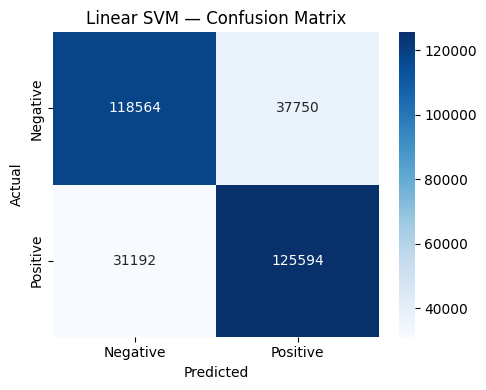


Top SVM keywords for Negative (0):
sad, dannygokeyislove, inaperfectworld, pass away, sadly, disapointe, unfortunately, poor, sadden, dontyouhate, gutte, gutted, could care, sadface, miss

Top SVM keywords for Positive (4):
let bed, wish luck, not wait, thesupergirl, nothing wrong, not hurt, iammaxathotspot, smilin, damn straight, give fuck, american reject, bad either, not bad, lol wonder, never fail


In [7]:
def top_keywords_from_linear(model, vectorizer, class_label: int, top_n: int = 15) -> List[str]:
    """Extract top keywords from linear model coefficients (handles binary + multiclass)."""
    if not hasattr(model, "coef_"):
        return []
    classes = list(getattr(model, "classes_", []))
    if class_label not in classes:
        return []

    feature_names = np.array(vectorizer.get_feature_names_out())
    coef_matrix = model.coef_

    # Binary SVM/LR: one hyperplane (shape 1 x n_features), not one row per class
    if coef_matrix.shape[0] == 1 and len(classes) == 2:
        coef = coef_matrix[0]
        positive_class = classes[1]
        if class_label == positive_class:
            top_idx = np.argsort(coef)[-top_n:][::-1]
        else:
            top_idx = np.argsort(coef)[:top_n]
    else:
        idx = classes.index(class_label)
        if idx >= coef_matrix.shape[0]:
            return []
        coef = coef_matrix[idx]
        top_idx = np.argsort(coef)[-top_n:][::-1]

    return feature_names[top_idx].tolist()


svm_model = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=3000, dual=False)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

svm_metrics = evaluate_classifier("Linear SVM", y_test, svm_pred, labels_present)
plot_confusion_matrix(y_test, svm_pred, labels_present, "Linear SVM — Confusion Matrix")
joblib.dump(svm_model, MODELS_DIR / "linear_svc.joblib")

for label in labels_present:
    print(f"\nTop SVM keywords for {SENTIMENT_MAP[label]} ({label}):")
    print(", ".join(top_keywords_from_linear(svm_model, tfidf, label)))


---
## Step 6 — Model 3: Logistic Regression

Train logistic regression with balanced class weights. Extract top positive/negative keywords from coefficients.


=== Logistic Regression ===
Accuracy    : 0.7840
Precision   : 0.7844
Recall      : 0.7840
F1          : 0.7840

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78    156314
           4       0.77      0.80      0.79    156786

    accuracy                           0.78    313100
   macro avg       0.78      0.78      0.78    313100
weighted avg       0.78      0.78      0.78    313100



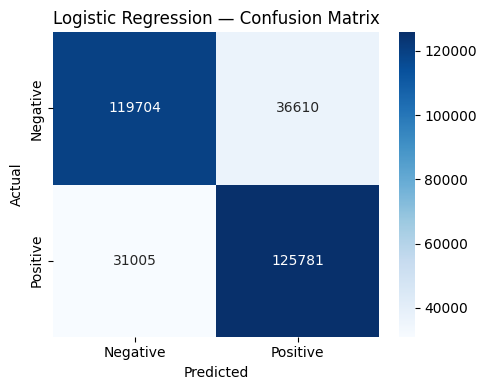


Logistic Regression — top keywords for Negative:
sad, sadly, miss, poor, unfortunately, sick, gutte, wish, bummed, upset, depressed, hurt

Logistic Regression — top keywords for Positive:
not wait, wish luck, thank, welcome, nothing wrong, smile, glad, not bad, proud, not hurt, yay, congratulation


In [8]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    solver="saga",
)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_proba = lr_model.predict_proba(X_test_tfidf)

lr_metrics = evaluate_classifier("Logistic Regression", y_test, lr_pred, labels_present)
plot_confusion_matrix(y_test, lr_pred, labels_present, "Logistic Regression — Confusion Matrix")
joblib.dump(lr_model, MODELS_DIR / "logistic_regression.joblib")

for label in labels_present:
    kw = top_keywords_from_linear(lr_model, tfidf, label, top_n=12)
    print(f"\nLogistic Regression — top keywords for {SENTIMENT_MAP[label]}:")
    print(", ".join(kw))


---
## Step 7 — Text tokenization for neural networks

Tokenize text, convert to sequences, and pad to fixed length. Uses **TensorFlow/Keras** when available, otherwise **Keras + PyTorch** (Python 3.13+).

In [9]:
from collections import Counter


class SimpleTokenizer:
    """Lightweight tokenizer when tf.keras.preprocessing is unavailable."""

    def __init__(self, num_words: int = 20_000, oov_token: str = "<OOV>"):
        self.num_words = num_words
        self.oov_token = oov_token
        self.word_index: Dict[str, int] = {}
        self.oov_index = 1

    def fit_on_texts(self, texts) -> None:
        counts = Counter()
        for text in texts:
            counts.update(str(text).split())
        self.word_index = {self.oov_token: self.oov_index}
        for word, _ in counts.most_common(self.num_words - 2):
            if word not in self.word_index:
                self.word_index[word] = len(self.word_index) + 1

    def texts_to_sequences(self, texts) -> List[List[int]]:
        return [
            [self.word_index.get(w, self.oov_index) for w in str(text).split()]
            for text in texts
        ]


def pad_text_sequences(sequences, maxlen: int, padding: str = "post", truncating: str = "post"):
    arr = np.zeros((len(sequences), maxlen), dtype=np.int32)
    for i, seq in enumerate(sequences):
        seq = list(seq)
        if truncating == "pre":
            seq = seq[-maxlen:]
        else:
            seq = seq[:maxlen]
        if padding == "post":
            arr[i, : len(seq)] = seq
        else:
            arr[i, -len(seq) :] = seq
    return arr


def setup_dl_backend():
    """Import Keras/TensorFlow for RNN/LSTM; fall back to Keras+PyTorch on Python 3.13+."""
    try:
        import tensorflow as tf

        tf.random.set_seed(RANDOM_STATE)
        for gpu in tf.config.list_physical_devices("GPU"):
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except Exception:
                pass
        from tensorflow.keras.callbacks import EarlyStopping
        from tensorflow.keras.layers import Dense, Embedding, LSTM, SimpleRNN
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.preprocessing.sequence import pad_sequences
        from tensorflow.keras.preprocessing.text import Tokenizer
        from tensorflow.keras.utils import to_categorical

        print(f"Deep learning backend: TensorFlow {tf.__version__}")
        return {
            "name": "tensorflow",
            "EarlyStopping": EarlyStopping,
            "Dense": Dense,
            "Embedding": Embedding,
            "LSTM": LSTM,
            "SimpleRNN": SimpleRNN,
            "Sequential": Sequential,
            "pad_sequences": pad_sequences,
            "Tokenizer": Tokenizer,
            "to_categorical": to_categorical,
        }
    except ImportError:
        import os

        os.environ.setdefault("KERAS_BACKEND", "torch")
        import keras

        keras.utils.set_random_seed(RANDOM_STATE)
        from keras.callbacks import EarlyStopping
        from keras.layers import Dense, Embedding, LSTM, SimpleRNN
        from keras.models import Sequential
        from keras.utils import to_categorical

        print(f"Deep learning backend: Keras {keras.__version__} (PyTorch)")
        return {
            "name": "keras_torch",
            "EarlyStopping": EarlyStopping,
            "Dense": Dense,
            "Embedding": Embedding,
            "LSTM": LSTM,
            "SimpleRNN": SimpleRNN,
            "Sequential": Sequential,
            "pad_sequences": pad_text_sequences,
            "Tokenizer": SimpleTokenizer,
            "to_categorical": to_categorical,
        }


dl = setup_dl_backend()
EarlyStopping = dl["EarlyStopping"]
Dense = dl["Dense"]
Embedding = dl["Embedding"]
LSTM = dl["LSTM"]
SimpleRNN = dl["SimpleRNN"]
Sequential = dl["Sequential"]
pad_sequences = dl["pad_sequences"]
Tokenizer = dl["Tokenizer"]
to_categorical = dl["to_categorical"]


df_nn = stratified_sample(df, MAX_NN_SAMPLES, RANDOM_STATE)
X_nn = df_nn["review_text"]
y_nn = df_nn["target"]

X_nn_train, X_nn_test, y_nn_train, y_nn_test = train_test_split(
    X_nn, y_nn, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_nn
)

try:
    tokenizer = Tokenizer(num_words=NN_MAX_VOCAB, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_nn_train)
    X_nn_train_seq = pad_sequences(
        tokenizer.texts_to_sequences(X_nn_train),
        maxlen=NN_MAX_SEQ_LEN,
        padding="post",
        truncating="post",
    ).astype(np.int32)
    X_nn_test_seq = pad_sequences(
        tokenizer.texts_to_sequences(X_nn_test),
        maxlen=NN_MAX_SEQ_LEN,
        padding="post",
        truncating="post",
    ).astype(np.int32)
except Exception as exc:
    raise RuntimeError(f"Tokenizer error: {exc}") from exc

label_to_idx = {label: i for i, label in enumerate(labels_present)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
num_classes = len(labels_present)

y_nn_train_idx = y_nn_train.map(label_to_idx).to_numpy()
y_nn_test_idx = y_nn_test.map(label_to_idx).to_numpy()
y_nn_train_oh = to_categorical(y_nn_train_idx, num_classes=num_classes)

print(f"NN train sequences: {X_nn_train_seq.shape}, classes: {num_classes}, backend: {dl['name']}")

X_nn_eval_seq, y_nn_eval = nn_eval_subset(X_nn_test_seq, y_nn_test, NN_EVAL_MAX_SAMPLES)
print(f"NN test: {len(X_nn_test_seq):,} rows | eval subset: {len(X_nn_eval_seq):,} rows")


Deep learning backend: Keras 3.14.1 (PyTorch)
Sampled 150,000 rows (from 1,565,497) for modeling.
NN train sequences: (120000, 60), classes: 2, backend: keras_torch
NN test: 30,000 rows | eval subset: 30,000 rows


---
## Step 8 — Model 4: Simple RNN

Build a simple RNN with an embedding layer.

> **Speed:** RNN/LSTM use `MAX_NN_SAMPLES` (default 150k) and shorter sequences (`NN_MAX_SEQ_LEN=60`) so CPU training finishes in minutes, not ~30 min. Set `MAX_NN_SAMPLES=None` only if you have a GPU or time for full-data training.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - accuracy: 0.6460 - loss: 0.6213 - val_accuracy: 0.7217 - val_loss: 0.5630
Epoch 2/2
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 439ms/step - accuracy: 0.7612 - loss: 0.5097 - val_accuracy: 0.7258 - val_loss: 0.5572

=== Simple RNN ===
Accuracy    : 0.7229
Precision   : 0.7264
Recall      : 0.7229
F1          : 0.7218

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.66      0.70     14977
           4       0.70      0.79      0.74     15023

    accuracy                           0.72     30000
   macro avg       0.73      0.72      0.72     30000
weighted avg       0.73      0.72      0.72     30000



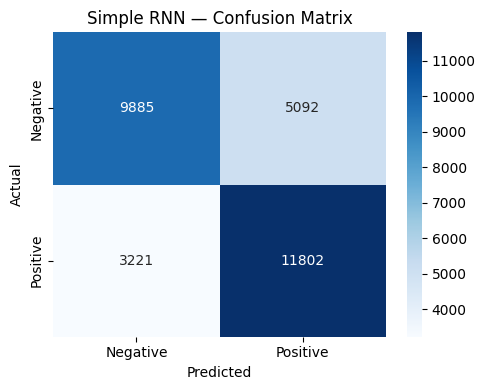

In [10]:
EMBED_DIM = NN_EMBED_DIM
RNN_UNITS = NN_RNN_UNITS
EPOCHS = NN_EPOCHS
BATCH_SIZE = NN_BATCH_SIZE

vocab_size = min(NN_MAX_VOCAB, len(tokenizer.word_index) + 1)

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=NN_MAX_SEQ_LEN),
    SimpleRNN(RNN_UNITS),
    Dense(num_classes, activation="softmax"),
])
rnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
rnn_model.summary()

rnn_history = rnn_model.fit(
    X_nn_train_seq,
    y_nn_train_oh,
    validation_split=NN_VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)],
    verbose=1,
)

rnn_proba = rnn_model.predict(X_nn_eval_seq, batch_size=NN_PREDICT_BATCH_SIZE, verbose=0)
rnn_pred = pd.Series(rnn_proba.argmax(axis=1)).map(idx_to_label)
rnn_conf = rnn_proba.max(axis=1)

rnn_metrics = evaluate_classifier("Simple RNN", y_nn_eval, rnn_pred, labels_present)
plot_confusion_matrix(y_nn_eval, rnn_pred, labels_present, "Simple RNN — Confusion Matrix")
rnn_model.save(MODELS_DIR / "simple_rnn.keras")


---
## Step 9 — Model 5: LSTM

Build an LSTM model with an embedding layer. Train, evaluate, and output predictions with confidence scores.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
56/56 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5003 - loss: 0.6932 - val_accuracy: 0.4982 - val_loss: 0.6932
Epoch 2/2
56/56 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5007 - loss: 0.6932 - val_accuracy: 0.4982 - val_loss: 0.6933

=== LSTM ===
Accuracy    : 0.4992
Precision   : 0.2492
Recall      : 0.4992
F1          : 0.3325

Classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     14977
           4       0.00      0.00      0.00     15023

    accuracy                           0.50     30000
   macro avg       0.25      0.50      0.33     30000
weighted avg       0.25      0.50      0.33     30000



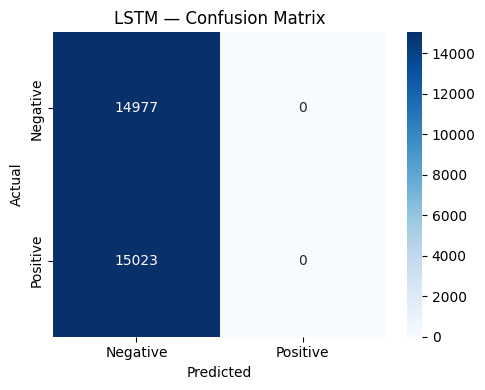

In [11]:
if not RUN_LSTM:
    print("Skipping LSTM (RUN_LSTM=False)")
else:
    lstm_model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=NN_MAX_SEQ_LEN),
        LSTM(RNN_UNITS),
        Dense(num_classes, activation="softmax"),
    ])
    lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    lstm_model.summary()

    lstm_history = lstm_model.fit(
        X_nn_train_seq,
        y_nn_train_oh,
        validation_split=NN_VAL_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)],
        verbose=1,
    )

    lstm_proba = lstm_model.predict(X_nn_eval_seq, batch_size=NN_PREDICT_BATCH_SIZE, verbose=0)
    lstm_pred = pd.Series(lstm_proba.argmax(axis=1)).map(idx_to_label)
    lstm_conf = lstm_proba.max(axis=1)

    lstm_metrics = evaluate_classifier("LSTM", y_nn_eval, lstm_pred, labels_present)
    plot_confusion_matrix(y_nn_eval, lstm_pred, labels_present, "LSTM — Confusion Matrix")
    lstm_model.save(MODELS_DIR / "lstm.keras")


---
## Step 10 — Model 6: DistilBERT

Fine-tune **DistilBERT** (`distilbert-base-uncased`) for sentiment classification. Outputs predicted sentiment, confidence scores, and sample important tokens. Falls back to **CPU** if no GPU is available.

In [ ]:
bert_metrics = None
bert_pred = None
bert_proba = None
bert_test_labels = None

if not RUN_BERT:
    print("Skipping BERT (RUN_BERT=False).")
else:
    try:
        import torch
        from torch.utils.data import Dataset
        from transformers import (
            AutoModelForSequenceClassification,
            AutoTokenizer,
            Trainer,
            TrainingArguments,
        )

        torch.set_num_threads(CPU_COUNT)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"BERT device: {device}")

        df_bert = stratified_sample(df, MAX_BERT_SAMPLES, RANDOM_STATE)
        bert_texts = df_bert["review_text"].tolist()
        bert_targets = df_bert["target"].tolist()
        bert_label_ids = df_bert["target"].map(label_to_idx).tolist()

        bert_texts_train, bert_texts_test, bert_ids_train, bert_ids_test, _, bert_targets_test = train_test_split(
            bert_texts,
            bert_label_ids,
            bert_targets,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=bert_label_ids,
        )

        id2label = {i: str(label) for label, i in label_to_idx.items()}
        label2id = {str(label): i for label, i in label_to_idx.items()}

        MODEL_NAME = "distilbert-base-uncased"
        bert_tok = AutoTokenizer.from_pretrained(MODEL_NAME)

        class SentimentDataset(Dataset):
            def __init__(self, texts, labels):
                self.texts = texts
                self.labels = labels

            def __len__(self):
                return len(self.texts)

            def __getitem__(self, idx):
                enc = bert_tok(
                    self.texts[idx],
                    truncation=True,
                    padding="max_length",
                    max_length=BERT_MAX_LENGTH,
                    return_tensors="pt",
                )
                item = {k: v.squeeze(0) for k, v in enc.items()}
                item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
                return item

        train_ds = SentimentDataset(bert_texts_train, bert_ids_train)
        test_ds = SentimentDataset(bert_texts_test, bert_ids_test)

        bert_model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=num_classes,
            id2label=id2label,
            label2id=label2id,
        )
        bert_model.to(device)

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=-1)
            return {
                "accuracy": accuracy_score(labels, preds),
                "f1": f1_score(labels, preds, average="weighted", zero_division=0),
            }

        import inspect

        _ta_params = inspect.signature(TrainingArguments.__init__).parameters
        _train_kw = dict(
            output_dir=str(MODELS_DIR / "distilbert"),
            num_train_epochs=BERT_EPOCHS,
            per_device_train_batch_size=BERT_TRAIN_BATCH,
            per_device_eval_batch_size=BERT_EVAL_BATCH,
            learning_rate=2e-5,
            weight_decay=0.01,
            save_strategy="no",
            logging_steps=50,
            report_to="none",
            dataloader_num_workers=NUM_WORKERS,
            dataloader_pin_memory=torch.cuda.is_available(),
            fp16=torch.cuda.is_available(),
        )
        # transformers >=4.41 renamed evaluation_strategy -> eval_strategy
        if "eval_strategy" in _ta_params:
            _train_kw["eval_strategy"] = "epoch"
        else:
            _train_kw["evaluation_strategy"] = "epoch"
        if "no_cuda" in _ta_params:
            _train_kw["no_cuda"] = not torch.cuda.is_available()
        train_args = TrainingArguments(**_train_kw)

        trainer = Trainer(
            model=bert_model,
            args=train_args,
            train_dataset=train_ds,
            eval_dataset=test_ds,
            compute_metrics=compute_metrics,
        )
        print(f"Fine-tuning DistilBERT on {len(train_ds):,} samples...")
        trainer.train()
        eval_out = trainer.evaluate()
        print(f"Eval loss: {eval_out.get('eval_loss', float('nan')):.4f} | eval accuracy: {eval_out.get('eval_accuracy', float('nan')):.4f}")

        def bert_predict_proba(texts: List[str], batch_size: int = BERT_EVAL_BATCH) -> np.ndarray:
            bert_model.eval()
            chunks = []
            with torch.no_grad():
                for start in range(0, len(texts), batch_size):
                    batch = texts[start : start + batch_size]
                    enc = bert_tok(
                        batch,
                        truncation=True,
                        padding=True,
                        max_length=BERT_MAX_LENGTH,
                        return_tensors="pt",
                    )
                    enc = {k: v.to(device) for k, v in enc.items()}
                    logits = bert_model(**enc).logits
                    chunks.append(torch.softmax(logits, dim=-1).cpu().numpy())
            return np.vstack(chunks)

        bert_proba = bert_predict_proba(bert_texts_test)
        bert_pred_idx = bert_proba.argmax(axis=1)
        bert_pred = pd.Series(bert_pred_idx).map(idx_to_label)
        bert_test_labels = pd.Series(bert_targets_test)

        bert_metrics = evaluate_classifier("DistilBERT", bert_test_labels, bert_pred, labels_present)
        plot_confusion_matrix(bert_test_labels, bert_pred, labels_present, "DistilBERT — Confusion Matrix")

        trainer.save_model(str(MODELS_DIR / "distilbert" / "final"))
        bert_tok.save_pretrained(str(MODELS_DIR / "distilbert" / "final"))

        print("\nSample DistilBERT predictions:")
        sample_df = pd.DataFrame({
            "review_text": bert_texts_test[:8],
            "actual": bert_test_labels.iloc[:8].map(map_sentiment_label),
            "predicted": bert_pred.iloc[:8].map(map_sentiment_label),
            "confidence": np.round(bert_proba[:8].max(axis=1), 4),
        })
        display(sample_df)

        def bert_important_tokens(text: str, top_n: int = 5) -> List[str]:
            """Highlight tokens with highest attention to [CLS] (proxy for importance)."""
            bert_model.eval()
            enc = bert_tok(text, truncation=True, padding="max_length", max_length=BERT_MAX_LENGTH, return_tensors="pt")
            enc = {k: v.to(device) for k, v in enc.items()}
            with torch.no_grad():
                outputs = bert_model.distilbert(**{k: enc[k] for k in ("input_ids", "attention_mask")}, output_attentions=True)
            # last layer attention: (batch, heads, seq, seq)
            attn = outputs.attentions[-1][0].mean(dim=0)
            cls_scores = attn[0, : enc["attention_mask"].sum().item()]
            tokens = bert_tok.convert_ids_to_tokens(enc["input_ids"][0][: len(cls_scores)])
            ranked = sorted(zip(tokens, cls_scores.cpu().numpy()), key=lambda x: x[1], reverse=True)
            keep = []
            for tok, _ in ranked:
                if tok in ("[CLS]", "[SEP]", "[PAD]"):
                    continue
                clean = tok.replace("##", "")
                if clean and clean not in keep:
                    keep.append(clean)
                if len(keep) >= top_n:
                    break
            return keep

        print("\nImportant tokens (attention proxy) for first test review:")
        if bert_texts_test:
            print(", ".join(bert_important_tokens(bert_texts_test[0])))

    except ImportError as exc:
        print(f"BERT skipped — install transformers and torch: {exc}")
    except Exception as exc:
        print(f"BERT training failed: {exc}")


BERT device: cpu
Using full dataset: 1,565,497 rows.


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1876.76it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT on 1,252,397 samples...


---
## Step 11 — Sentiment label mapping

Map numeric predictions (`0`, `2`, `4`) to human-readable labels.

In [12]:
print(map_sentiment_label(0), map_sentiment_label(2), map_sentiment_label(4))
pd.Series(lr_pred).map(map_sentiment_label).head(10)


Negative Neutral Positive


0    Negative
1    Negative
2    Negative
3    Positive
4    Positive
5    Negative
6    Positive
7    Positive
8    Positive
9    Positive
dtype: str

---
## Step 12 — Extract important keywords

For ML models, combine TF-IDF features with model coefficients. For DL models, reuse ML keywords per review (attention/LIME optional).

In [13]:
def keywords_for_text(text: str, model, vectorizer, class_label: int, top_n: int = 5) -> List[str]:
    global_kw = top_keywords_from_linear(model, vectorizer, class_label, top_n=top_n)
    if not global_kw:
        return []
    text_tokens = set(re.findall(r"[a-z0-9]+", text.lower()))
    matched = [kw for kw in global_kw if kw in text_tokens]
    return matched if matched else global_kw[:top_n]


def attach_keywords(df_out: pd.DataFrame, preds, proba, model, vectorizer) -> pd.DataFrame:
    df_out = df_out.copy()
    df_out["predicted_target"] = preds
    df_out["predicted_sentiment"] = df_out["predicted_target"].map(map_sentiment_label)
    df_out["confidence_score"] = np.round(proba.max(axis=1), 4)

    texts = df_out["cleaned_review_text"].tolist()
    targets = df_out["predicted_target"].tolist()
    n_chunks = max(1, min(PARALLEL_TEXT_JOBS, len(texts)))
    chunks = np.array_split(np.arange(len(texts)), n_chunks)

    def _chunk_keywords(idxs):
        return [
            ", ".join(keywords_for_text(texts[i], model, vectorizer, int(targets[i])))
            for i in idxs
        ]

    if len(texts) >= 100_000:
        df_out["important_keywords"] = _chunk_keywords(np.arange(len(texts)))
    else:
        kw_parts = Parallel(n_jobs=PARALLEL_TEXT_JOBS, prefer="threads")(
            delayed(_chunk_keywords)(chunk) for chunk in chunks
        )
        df_out["important_keywords"] = [x for part in kw_parts for x in part]
    return df_out

print("Keyword helpers ready (parallel).")


Keyword helpers ready (parallel).


---
## Step 13 — Complaint category classification

Rule-based keyword mapping assigns each review to a complaint category (or `general` if no rule matches).

In [14]:
def classify_complaint(text: str) -> str:
    if not text or pd.isna(text):
        return "general"
    lower = str(text).lower()
    for category, keywords in COMPLAINT_RULES.items():
        if any(kw in lower for kw in keywords):
            return category
    return "general"


for s in [
    "delivery was late and package damaged",
    "want a refund for this broken item",
    "customer service was rude on the call",
    "love this product great quality",
]:
    print(f"{classify_complaint(s):20s} | {s}")


delivery_issue       | delivery was late and package damaged
product_quality      | want a refund for this broken item
customer_service     | customer service was rude on the call
product_quality      | love this product great quality


---
## Step 14 — Final output DataFrame

Build the final results table using **Logistic Regression** (probabilities + interpretable keywords). Save **`sentiment_results_phase4.csv`**.

In [15]:
export_df = df_ml.loc[X_test.index]
export_df = export_df.assign(cleaned_review_text=export_df["review_text"])

results = attach_keywords(export_df, lr_pred, lr_proba, lr_model, tfidf)
texts = results["cleaned_review_text"].tolist()
if len(texts) >= 100_000:
    results["complaint_category"] = [classify_complaint(t) for t in texts]
else:
    idx_chunks = np.array_split(np.arange(len(texts)), max(1, PARALLEL_TEXT_JOBS))
    cat_parts = Parallel(n_jobs=PARALLEL_TEXT_JOBS, prefer="threads")(
        delayed(lambda ix: [classify_complaint(texts[i]) for i in ix])(chunk) for chunk in idx_chunks
    )
    results["complaint_category"] = [x for part in cat_parts for x in part]

final_cols = [
    "cleaned_review_text",
    "predicted_sentiment",
    "confidence_score",
    "important_keywords",
    "complaint_category",
]
if "row_id" in results.columns:
    final_cols = ["row_id", "target"] + final_cols

final_output = results[final_cols].copy()

if OUTPUT_MAX_ROWS is not None and len(final_output) > OUTPUT_MAX_ROWS:
    final_output = final_output.head(OUTPUT_MAX_ROWS).copy()
    print(f"Capped final output to {OUTPUT_MAX_ROWS:,} rows.")

final_output.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Saved {len(final_output):,} rows to {OUTPUT_CSV.name}")
display(final_output.head(10))

all_metrics = [nb_metrics, svm_metrics, lr_metrics, rnn_metrics, lstm_metrics]
if bert_metrics is not None:
    all_metrics.append(bert_metrics)

metrics_df = pd.DataFrame(all_metrics)
print("\nModel comparison:")
display(metrics_df)


KeyboardInterrupt: 

**Tips:**
- **RNN/LSTM slow?** Lower `MAX_NN_SAMPLES`, `NN_MAX_SEQ_LEN`, or set `RUN_LSTM=False`.
- **Full DL training:** Set `MAX_NN_SAMPLES=None` and use a GPU if available.
- Set `MAX_ML_SAMPLES` / `MAX_BERT_SAMPLES` to subsample other models.
- Increase `NUM_WORKERS` if you have more CPU cores and RAM headroom.
